In [1]:
from resources.imports import *

from resources.lattices import geometry, pStrainProperties, effProperties
from resources.MLdata import DATA, load_data, prep_UTdata, prep_FTdata, remove_outliers, split_data, plot_sampling,\
                             locSims, get_stats, plot_frequency, plot_properties, plot_curve

In [2]:
### Global Inputs

MODEL = 'ductile'      # ductile, fracture, both
FREQ = False
DAT = DATA(path=1,
           path_add="",
           LAT="FCC", 
           dis="disNodes", 
           dN=0.2)

l = 0.010
if DAT.LAT.lower() == "fcc" or DAT.LAT.lower() == "kagome" or DAT.LAT.lower() == "hex":
    nnx = 20
elif DAT.LAT.lower() == "tri":
    nnx = 30

# Load Data

In [3]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    UT_CSVin  = DAT.PATH + f'Ductile-{DAT.dis}-IN.csv'
    UT_CSVout = DAT.PATH + f'Ductile-{DAT.dis}-OUT.csv'
    UT_CSVin_f = None
    if FREQ:
        UT_CSVin_f = DAT.PATH + f'Ductile-{DAT.dis}-INf.csv'

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    FT_CSVin  = DAT.PATH + f'Fracture-{DAT.dis}-IN.csv'
    FT_CSVout = DAT.PATH + f'Fracture-{DAT.dis}-OUT.csv'
    FT_CSVin_f = None
    if FREQ:
        FT_CSVin_f = DAT.PATH + f'Fracture-{DAT.dis}-INf.csv'

In [4]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    UT_IN_df, UT_OUT_df, UT_INf_df, UT_perIN_df, UT_perOUT_df, UT_dIN_df, UT_dOUT_df = load_data(UT_CSVin, UT_CSVout, UT_CSVin_f)

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    FT_IN_df, FT_OUT_df, FT_INf_df, FT_perIN_df, FT_perOUT_df, FT_dIN_df, FT_dOUT_df = load_data(FT_CSVin, FT_CSVout, FT_CSVin_f)

# Geometry

In [5]:
geom = geometry(DAT.LAT, l, nnx, FTcalc=True)

E = 123e9  ## Pa
v = 0.3
rD = 0.2
E_pStrain, v_pStrain = pStrainProperties(E, v)
E_eff, v_eff = effProperties(DAT.LAT, E_pStrain, rD)

# Prep Data

In [6]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    UT_dIN_r, UT_dOUT_r, UT_INf_r, UT_xOUT, UT_props_r = prep_UTdata(UT_dIN_df, UT_dOUT_df, UT_perOUT_df, UT_OUT_df, UT_INf_df)
    UT_dIN, UT_dOUT, UT_INf, UT_props, UT_IN_df, UT_OUT_df, UT_dIN_df, UT_dOUT_df, UT_INf_df = remove_outliers(UT_dIN_r, UT_dOUT_r, UT_props_r, UT_IN_df, UT_OUT_df, UT_dIN_df, UT_dOUT_df, UT_INf_r, UT_INf_df)
    UT_train_in, UT_train_out, UTval_in, UTval_out, UT_test_in, UT_test_out, UT_train_in_f, UT_val_in_f, UT_test_in_f = split_data(UT_dIN[1:], UT_dOUT[1:], DAT.PATH, "UT", DAT.dis, UT_INf, split=0.85)

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    FT_dIN_r, FT_dOUT_r, FT_INf_r, FT_xOUT, FT_props_r = prep_FTdata(FT_dIN_df, FT_dOUT_df, FT_perOUT_df, FT_OUT_df, geom, E_eff, FT_INf_df)
    FT_dIN, FT_dOUT, FT_INf, FT_props, FT_IN_df, FT_OUT_df, FT_dIN_df, FT_dOUT_df, FT_INf_df = remove_outliers(FT_dIN_r, FT_dOUT_r, FT_props_r, FT_IN_df, FT_OUT_df, FT_dIN_df, FT_dOUT_df, FT_INf_r, FT_INf_df)
    FT_train_in, FT_train_out, FT_val_in, FT_val_out, FT_test_in, FT_test_out, FT_train_in_f, FT_val_in_f, FT_test_in_f = split_data(FT_dIN[1:], FT_dOUT[1:], DAT.PATH, "FT", DAT.dis, FT_INf, split=0.85)

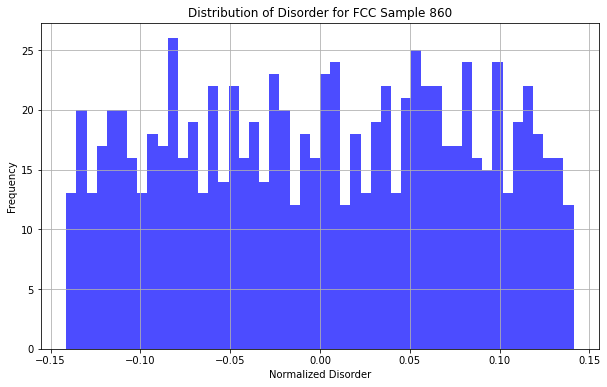

In [7]:
plot_sampling(UT_dIN_df, DAT.LAT, l, indx=None, num=1, by="Sample")

In [8]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    UT_stats = get_stats(UT_props)
    UT_nSim_max, UT_nSim_min = locSims(UT_props[0], UT_OUT_df)
    print("FINAL SIMULATION COUNT:", len(UT_OUT_df)-1)
    print(f"UT -- max: {UT_nSim_max}, min: {UT_nSim_min} \nStats: {np.array(UT_stats)/UT_props[0][0]} \n")
if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    FT_stats = get_stats(FT_props)
    FT_nSim_max, FT_nSim_min = locSims(FT_props[0], FT_OUT_df)
    print("FINAL SIMULATION COUNT:", len(FT_OUT_df)-1)
    print(f"FT -- max: {FT_nSim_max}, min: {FT_nSim_min} \nStats: {np.array(FT_stats)/FT_props[0][0]} \n")

FINAL SIMULATION COUNT: 986
UT -- max: 337, min: 894 
Stats: [[1.27764430e+00 1.74453730e-01]
 [2.22229344e+03 3.07791945e+01]
 [3.28352541e+05 1.34460045e+03]] 



# Plot Distribution & Identify Max, Min Simulations

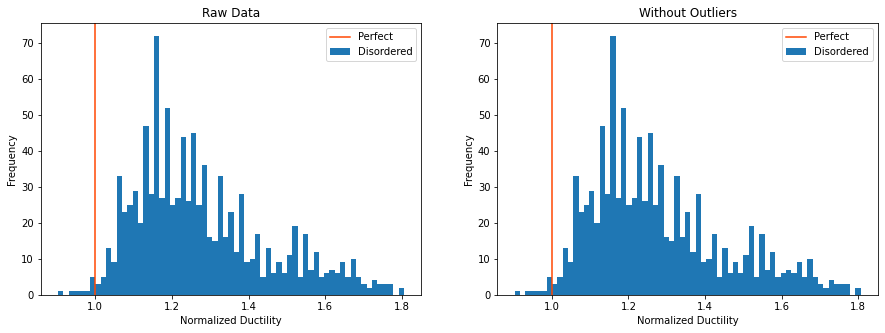

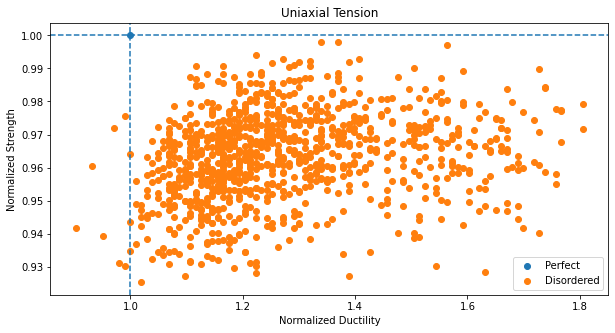

In [9]:
plot_freq = True
plot_props = True

dduct, sstr, sstiff = 0, 1, 2
kk, FF, dd = 0, 2, 3

U1, U2 = dduct, sstr
F1, F2 = kk, dd

if plot_freq:
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        plot_frequency(UT_props_r[U1], UT_props[U1], "UT", bins=len(UT_props[U1])//15)
    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        plot_frequency(FT_props_r[F1], FT_props[F1], "FT", bins=len(FT_props[U1])//15)

if plot_props:
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        plot_properties(UT_props[U1], UT_props[U2], "UT")
    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        plot_properties(FT_props[F1], FT_props[F2], "FT")

# Plots UT and FT Curves

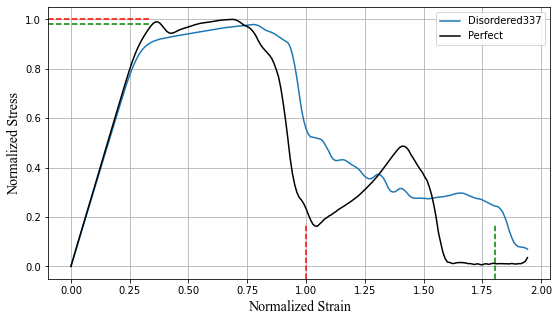

In [10]:
idx = 337
q   = "all"
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    plot_curve(UT_OUT_df, UT_xOUT, "ut", pi=0, idx=idx, q='all')
    
if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    plot_curve(FT_OUT_df, FT_xOUT, "ft", pi=0, idx=idx, q='all')